# Блок 7. Основы искусственного интеллекта и машинного обучения
## Занятие 6. Метрики классификации и Confusion Matrix

## Цель занятия

На прошлом занятии мы построили первую модель классификации через `LogisticRegression`.

Сегодня подробно разбираем, как оценивать качество классификатора.

Изучаем:

- `Confusion Matrix`;
- `TP`, `TN`, `FP`, `FN`;
- `Accuracy`;
- `Precision`;
- `Recall`;
- `F1-score`;
- визуализацию матрицы ошибок;
- анализ ошибок модели.

---

## Почему Accuracy недостаточно

Accuracy показывает долю правильных ответов.

Но иногда этого мало.

Пример:

Если в задаче 95% писем не спам, модель может всегда говорить «не спам» и получить Accuracy 95%.

Но такая модель бесполезна, потому что она не находит спам.

Поэтому нужны дополнительные метрики:

- Precision;
- Recall;
- F1-score.

---

## Confusion Matrix простыми словами

Матрица ошибок показывает, где модель ошиблась.

Для бинарной классификации есть 4 варианта:

| Обозначение | Смысл |
|---|---|
| TP | модель сказала 1, и правильный ответ 1 |
| TN | модель сказала 0, и правильный ответ 0 |
| FP | модель сказала 1, но правильный ответ 0 |
| FN | модель сказала 0, но правильный ответ 1 |

---

## Метрики

### Accuracy

Сколько всего ответов правильные.

### Precision

Из тех, кого модель назвала положительным классом, сколько действительно положительные.

### Recall

Из всех настоящих положительных объектов, сколько модель нашла.

### F1-score

Средний баланс между Precision и Recall.

---

## Датасет занятия

Используем встроенный датасет Breast Cancer из Scikit-Learn.

Задача:

- определить класс медицинского объекта по числовым признакам;
- построить модель классификации;
- оценить качество модели.

---

## Связь с дипломом

Метрики классификации нужны в проектах:

- медицина: болен / здоров;
- HR: подходит / не подходит;
- банк: рискованный клиент / надёжный клиент;
- продажи: купит / не купит;
- безопасность: мошенничество / обычная операция.

---

## GitHub

```bash
git checkout main
git pull origin main
git checkout -b feature/block7-lesson06-classification-metrics

git add .
git commit -m "feat: add classification metrics lesson"
git push -u origin feature/block7-lesson06-classification-metrics
```

## Ячейка 1. Импорт библиотек

### Алгоритм

1. Импортируем библиотеки для данных.
2. Импортируем инструменты Scikit-Learn.
3. Импортируем метрики классификации.
4. Импортируем matplotlib для графиков.

Сегодня основное внимание — на оценке качества модели.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Библиотеки подключены")

assert pd is not None

Библиотеки подключены


## Ячейка 2. Загрузка датасета

### Алгоритм

1. Загружаем датасет Breast Cancer.
2. Создаём DataFrame с признаками.
3. Создаём Series с целевой переменной.
4. Проверяем размеры.

Датасет уже встроен в Scikit-Learn, поэтому интернет не нужен.

названия классов ('malignant' и 'benign') взяты непосредственно из датасета load_breast_cancer(), который мы загрузили. Они представляют собой метки для целевой переменной, где 'malignant' (злокачественный) обычно соответствует классу 0, а 'benign' (доброкачественный) — классу 1. data.target_names возвращает эти удобочитаемые имена классов из объекта датасета.

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Классы:", data.target_names)

assert len(X) == len(y)
assert X.shape[1] > 10

Размер X: (569, 30)
Размер y: (569,)
Классы: ['malignant' 'benign']


## Ячейка 3. Распределение классов

### Алгоритм

1. Считаем количество объектов каждого класса.
2. Строим bar chart.
3. Проверяем, что классов два.

Важно понимать баланс классов до обучения модели.

Распределение классов:
target
0    212
1    357
Name: count, dtype: int64


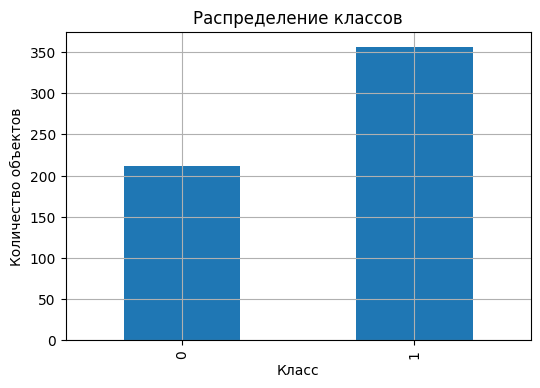

In [3]:
class_counts = y.value_counts().sort_index()

print("Распределение классов:")
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.grid(True)
plt.show()

assert len(class_counts) == 2
assert class_counts.sum() == len(y)

## Ячейка 4. Разделение данных

### Алгоритм

1. Делим данные на train и test.
2. Используем `stratify=y`, чтобы сохранить пропорции классов.
3. Проверяем размеры.

Для классификации `stratify` часто полезен, особенно если классы несбалансированы.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

assert len(X_train) > len(X_test)
assert len(X_train) + len(X_test) == len(X)

Train: (455, 30)
Test: (114, 30)


## Ячейка 5. Масштабирование и обучение модели

### Алгоритм

1. Создаём `StandardScaler`.
2. Обучаем scaler только на train.
3. Преобразуем train и test.
4. Обучаем Logistic Regression.

Важно: scaler обучается только на train, чтобы не было утечки данных.

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

print("Модель обучена")

assert X_train_scaled.shape == X_train.shape
assert model is not None

Модель обучена


## Ячейка 6. Предсказания модели

### Алгоритм

1. Получаем предсказанные классы через `predict`.
2. Получаем вероятности через `predict_proba`.
3. Сравниваем первые значения факта и прогноза.

Класс — это финальное решение модели.  
Вероятность показывает уверенность модели.

код выполняет несколько ключевых шагов для оценки вашей модели классификации:

y_pred = model.predict(X_test_scaled): Эта строка использует обученную модель (model), чтобы сделать окончательные предсказания классов (0 или 1) для масштабированных тестовых данных (X_test_scaled).
y_proba = model.predict_proba(X_test_scaled): Эта строка также использует обученную модель для предсказания, но вместо конкретного класса она возвращает вероятности принадлежности к каждому классу. Для бинарной классификации это будет двумерный массив, где первый столбец — вероятность класса 0, а второй — вероятность класса 1.
comparison = pd.DataFrame(...): Здесь создается DataFrame comparison, который объединяет фактические значения, предсказанные классы и вероятности для класса 1:
"fact": y_test.values: Содержит реальные (фактические) метки классов из тестового набора.
"prediction": y_pred: Содержит предсказанные моделью метки классов.
"probability_class_1": y_proba[:, 1]: Содержит вероятности того, что объект относится к положительному классу (классу 1).

In [6]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

comparison = pd.DataFrame({
    "fact": y_test.values,
    "prediction": y_pred,
    "probability_class_1": y_proba[:, 1]
})

display(comparison.head(10))

assert len(y_pred) == len(y_test)
assert y_proba.shape[1] == 2

,fact,prediction,probability_class_1
0,0,0,5.888242e-08
1,1,1,9.999887e-01
2,0,0,6.410825e-03
3,1,1,5.335085e-01
4,0,0,6.525001e-10
5,1,1,9.921604e-01
6,1,1,9.999828e-01
7,0,0,5.635275e-07
8,0,0,5.431637e-05
9,0,0,8.041849e-11


## Ячейка 7. Основные метрики классификации

### Алгоритм

1. Считаем Accuracy.
2. Считаем Precision.
3. Считаем Recall.
4. Считаем F1-score.
5. Сохраняем результат в словарь.

Эти метрики показывают качество модели с разных сторон.

код рассчитывает и выводит основные метрики качества классификации:

accuracy = accuracy_score(y_test, y_pred): Вычисляет Accuracy — общую долю правильных предсказаний модели. Это отношение числа правильных предсказаний к общему числу предсказаний.
precision = precision_score(y_test, y_pred): Вычисляет Precision — долю истинно положительных результатов среди всех результатов, которые модель предсказала как положительные. Высокий Precision означает, что модель хорошо избегает ложных срабатываний (FP).
recall = recall_score(y_test, y_pred): Вычисляет Recall (полноту) — долю истинно положительных результатов, которые модель смогла обнаружить, среди всех фактически положительных случаев. Высокий Recall означает, что модель хорошо находит все положительные случаи, избегая ложных пропусков (FN).
f1 = f1_score(y_test, y_pred): Вычисляет F1-score — гармоническое среднее Precision и Recall. Это метрика, которая стремится найти баланс между Precision и Recall, особенно полезна, когда классы несбалансированы.

In [7]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_report = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1
}

for key, value in metrics_report.items():
    print(key, ":", round(value, 4))

assert accuracy > 0.8
assert f1 > 0.8

accuracy : 0.9825
precision : 0.9861
recall : 0.9861
f1 : 0.9861


## Ячейка 8. Confusion Matrix

### Алгоритм

1. Строим матрицу ошибок.
2. Получаем значения TN, FP, FN, TP.
3. Выводим каждое значение отдельно.
4. Проверяем, что сумма элементов равна размеру теста.

Матрица ошибок помогает понять, какие именно ошибки делает модель.

Строка cm = confusion_matrix(y_test, y_pred) создает матрицу ошибок (Confusion Matrix). Эта функция берет два основных аргумента:

y_test: Это истинные метки классов из тестового набора данных, то есть реальные значения, которые мы пытаемся предсказать.
y_pred: Это предсказанные моделью метки классов для тех же тестовых данных.
В результате cm становится двумерным массивом (матрицей), которая показывает, сколько объектов каждого класса было правильно или неправильно классифицировано моделью. Это позволяет детально анализировать производительность модели, выходя за рамки простой Accuracy.
Код print(cm) просто выводит на экран саму матрицу ошибок cm. В данном случае cm — это NumPy массив, представляющий матрицу ошибок, которую мы рассчитали ранее.

Строка tn, fp, fn, tp = cm.ravel() выполняет несколько действий:

cm.ravel(): Этот метод "разворачивает" двумерный массив (в данном случае матрицу ошибок) в одномерный массив. Для матрицы 2x2 он вернет 4 элемента в плоской последовательности.
tn, fp, fn, tp = ...: Затем эти 4 элемента одномерного массива присваиваются соответствующим переменным: tn (True Negatives), fp (False Positives), fn (False Negatives) и tp (True Positives). Это удобный способ получить отдельные значения из матрицы ошибок для дальнейшего использования или анализа.

In [8]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

assert cm.sum() == len(y_test)

Confusion Matrix:
[[41  1]
 [ 1 71]]
TN: 41
FP: 1
FN: 1
TP: 71


## Ячейка 9. Визуализация матрицы ошибок и classification_report

### Алгоритм

1. Используем `ConfusionMatrixDisplay`.
2. Строим визуальную матрицу ошибок.
3. Печатаем `classification_report`.
4. Анализируем качество по каждому классу.

Это удобный формат для отчёта в дипломе.

Строка кода disp = ConfusionMatrixDisplay(...) инициализирует объект ConfusionMatrixDisplay, который предназначен для удобной визуализации матрицы ошибок.

confusion_matrix=cm: Здесь мы передаем уже рассчитанную матрицу ошибок (cm), которую мы получили ранее с помощью confusion_matrix(y_test, y_pred).
display_labels=data.target_names: Этот параметр используется для указания текстовых меток классов, которые будут отображаться на графике матрицы ошибок (например, 'malignant' и 'benign'), вместо просто числовых индексов (0 и 1). Это делает визуализацию гораздо более понятной и информативной.

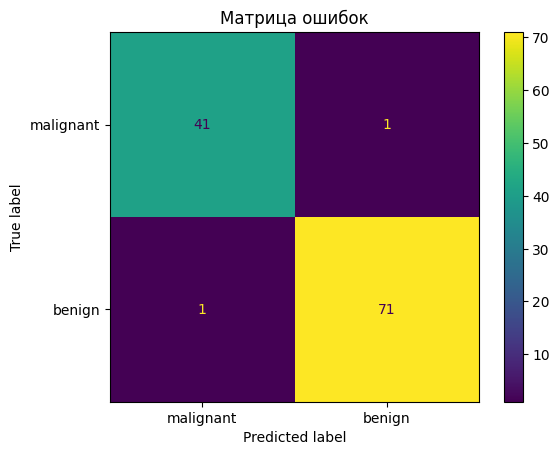

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [9]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Матрица ошибок")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

assert True

Матрица ошибок (Confusion Matrix) — это таблица, которая используется для оценки производительности модели классификации. Она показывает, насколько хорошо ваша модель справилась с предсказанием классов, сравнивая фактические (истинные) значения с предсказанными моделью.

Фактический результат — это реальный, правильный класс, к которому принадлежит объект в вашем наборе данных. Например, если мы классифицируем раковые опухоли, фактический результат может быть 'злокачественная' или 'доброкачественная'.

Матрица ошибок обычно имеет следующие компоненты для бинарной классификации (два класса, например, положительный и отрицательный):

True Positives (TP): Модель предсказала положительный класс, и фактический результат также был положительным. Это правильные предсказания.
True Negatives (TN): Модель предсказала отрицательный класс, и фактический результат также был отрицательным. Это также правильные предсказания.
False Positives (FP): Модель предсказала положительный класс, но фактический результат был отрицательным. Это ошибка типа I (ложное срабатывание).
False Negatives (FN): Модель предсказала отрицательный класс, но фактический результат был положительным. Это ошибка типа II (ложный пропуск).
По сути, матрица ошибок показывает, сколько объектов каждого истинного класса было классифицировано моделью как каждый из возможных классов. Это позволяет понять не только общую точность, но и типы ошибок, которые допускает ваша модель.

## Ячейка 10. Итоговый ML-отчёт

### Алгоритм

1. Собираем все метрики в словарь.
2. Добавляем элементы матрицы ошибок.
3. Формулируем выводы.
4. Выводим GitHub-команды.

Такой отчёт можно использовать как шаблон для дипломного проекта классификации.

In [10]:
final_report = {
    "rows": len(X),
    "features": X.shape[1],
    "accuracy": round(accuracy, 4),
    "precision": round(precision, 4),
    "recall": round(recall, 4),
    "f1": round(f1, 4),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}

print("Итоговый отчёт:")
for key, value in final_report.items():
    print(key, ":", value)

conclusions = [
    "Accuracy показывает общую долю правильных ответов.",
    "Precision показывает точность положительных предсказаний.",
    "Recall показывает, сколько положительных объектов модель нашла.",
    "F1-score помогает оценить баланс Precision и Recall.",
    "Confusion Matrix помогает увидеть конкретные типы ошибок модели."
]

print()
print("Выводы:")
for item in conclusions:
    print("-", item)

print()
print("GitHub:")
print("git add .")
print('git commit -m "feat: complete classification metrics lesson"')
print("git push -u origin feature/block7-lesson06-classification-metrics")

assert final_report["features"] > 10
assert len(conclusions) == 5

Итоговый отчёт:
rows : 569
features : 30
accuracy : 0.9825
precision : 0.9861
recall : 0.9861
f1 : 0.9861
tn : 41
fp : 1
fn : 1
tp : 71

Выводы:
- Accuracy показывает общую долю правильных ответов.
- Precision показывает точность положительных предсказаний.
- Recall показывает, сколько положительных объектов модель нашла.
- F1-score помогает оценить баланс Precision и Recall.
- Confusion Matrix помогает увидеть конкретные типы ошибок модели.

GitHub:
git add .
git commit -m "feat: complete classification metrics lesson"
git push -u origin feature/block7-lesson06-classification-metrics


# Итог занятия 6

Сегодня вы изучили:

- Accuracy;
- Precision;
- Recall;
- F1-score;
- Confusion Matrix;
- TP, TN, FP, FN;
- визуализацию матрицы ошибок;
- `classification_report`;
- итоговый ML-отчёт.

## Что показать преподавателю

- распределение классов;
- обученную модель;
- предсказания;
- вероятности;
- метрики;
- матрицу ошибок;
- выводы по качеству модели.

## GitHub

```bash
git add .
git commit -m "feat: add classification metrics lesson"
git push -u origin feature/block7-lesson06-classification-metrics
```